In [73]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_csv("wine.csv")

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [76]:

print(df.describe())

             Type     Alcohol       Malic         Ash  Alcalinity   Magnesium  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean     1.938202   13.000618    2.336348    2.366517   19.494944   99.741573   
std      0.775035    0.811827    1.117146    0.274344    3.339564   14.282484   
min      1.000000   11.030000    0.740000    1.360000   10.600000   70.000000   
25%      1.000000   12.362500    1.602500    2.210000   17.200000   88.000000   
50%      2.000000   13.050000    1.865000    2.360000   19.500000   98.000000   
75%      3.000000   13.677500    3.082500    2.557500   21.500000  107.000000   
max      3.000000   14.830000    5.800000    3.230000   30.000000  162.000000   

          Phenols  Flavanoids  Nonflavanoids  Proanthocyanins       Color  \
count  178.000000  178.000000     178.000000       178.000000  178.000000   
mean     2.295112    2.029270       0.361854         1.590899    5.058090   
std      0.625851    0.998859       0.1

In [77]:
print(df.isnull().sum())

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


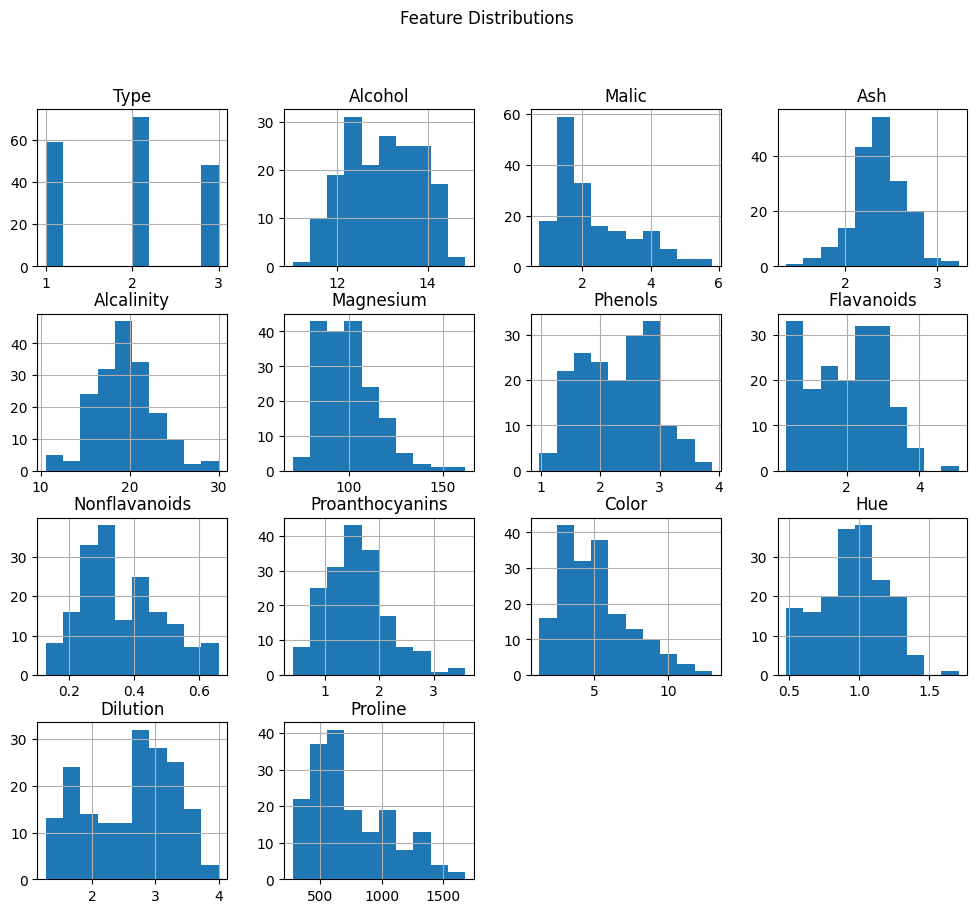

In [78]:
# Histograms

df.hist(figsize=(12,10))

plt.suptitle("Feature Distributions")

plt.show()

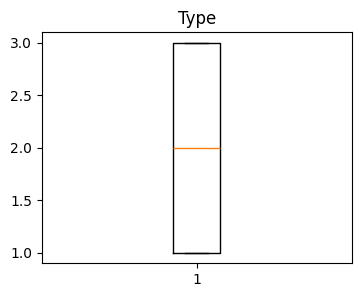

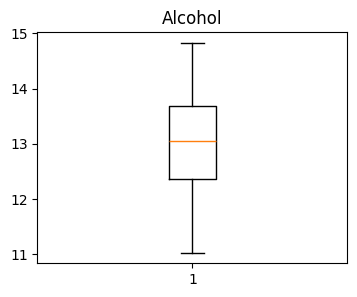

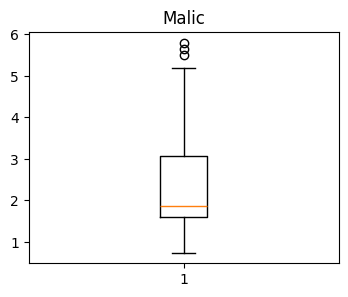

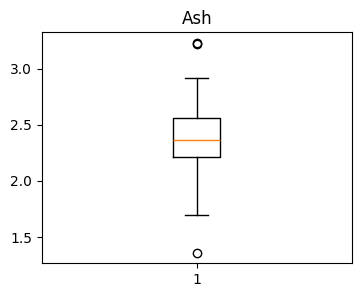

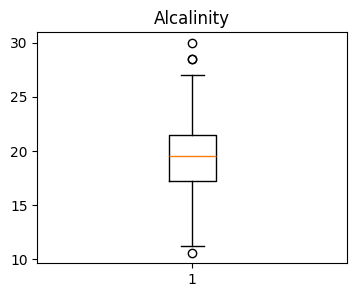

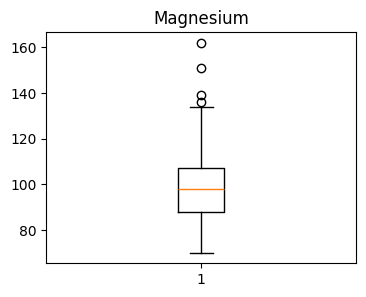

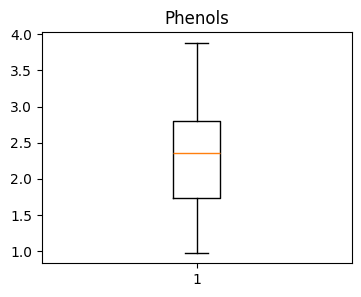

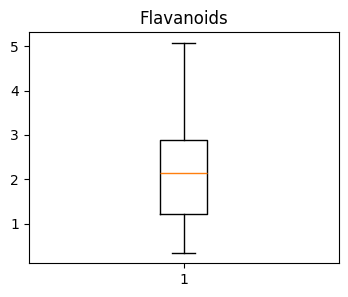

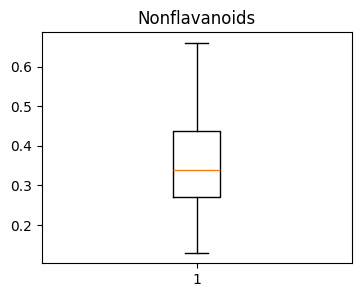

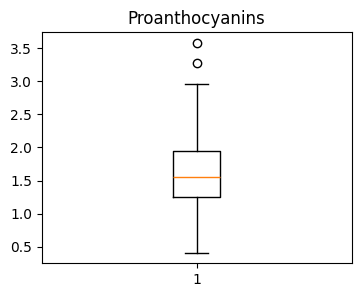

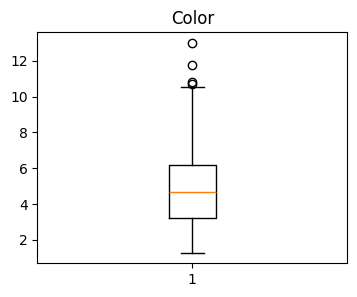

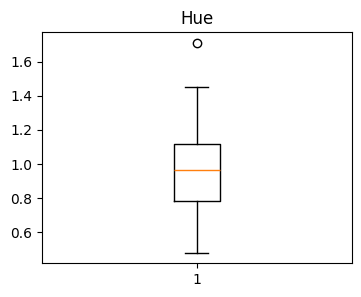

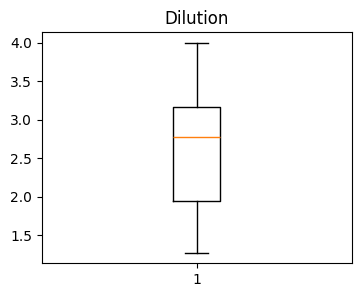

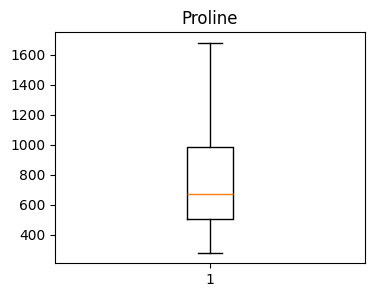

In [79]:
# Boxplots

for col in df.columns:

    plt.figure(figsize=(4,3))

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

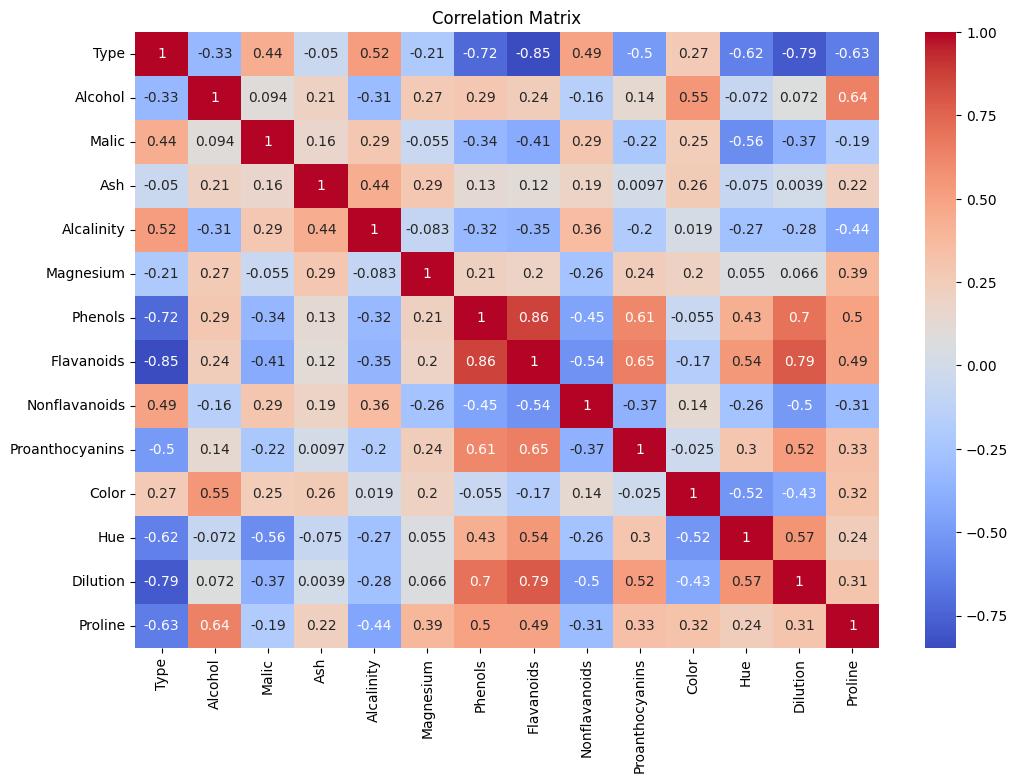

In [80]:
# Correlation matrix

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [81]:
# Features

X = df.drop("Type", axis=1)

In [82]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [83]:
# PCA

from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

PCA()

In [84]:
#variance ratio

print(pca.explained_variance_ratio_)

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


In [85]:
# Cumulative explained variance

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


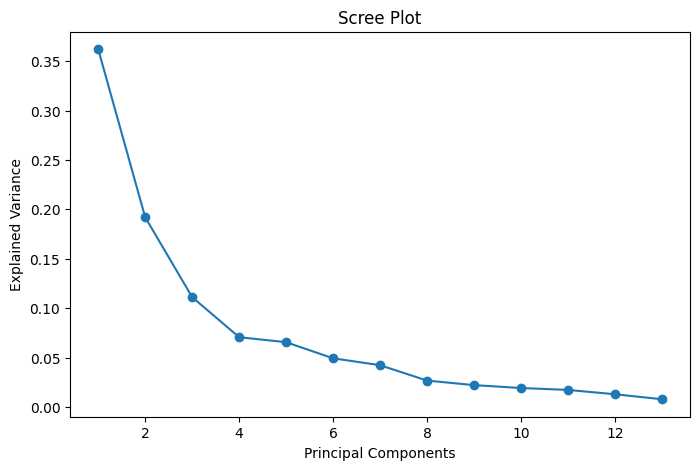

In [86]:
# Scree Plot

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Components")

plt.ylabel("Explained Variance")

plt.title("Scree Plot")

plt.show()

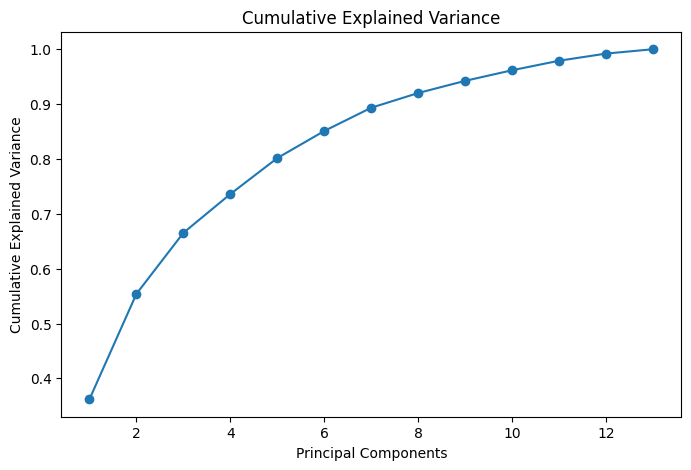

In [87]:
# Cumulative Explained Variance Plot

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Principal Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.show()

In [88]:
# PCA with 2 components

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(178, 2)


In [89]:
# PCA DataFrame

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(pca_df.head())

        PC1       PC2
0  3.316751  1.443463
1  2.209465 -0.333393
2  2.516740  1.031151
3  3.757066  2.756372
4  1.008908  0.869831


In [90]:
# K-Means on original data

from sklearn.cluster import KMeans

kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

original_clusters = kmeans_original.fit_predict(
    X_scaled
)

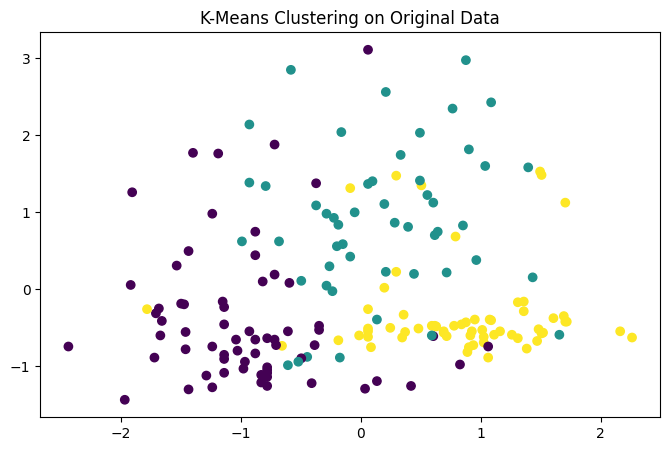

In [91]:
# Visualizing clusters

plt.figure(figsize=(8,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=original_clusters,
    cmap="viridis"
)

plt.title("K-Means Clustering on Original Data")

plt.show()

In [92]:
# Silhouette Score

from sklearn.metrics import silhouette_score

original_silhouette = silhouette_score(
    X_scaled,
    original_clusters
)

print("Silhouette Score :",
      original_silhouette)

Silhouette Score : 0.2848589191898987


In [93]:
# Davies-Bouldin Index

from sklearn.metrics import davies_bouldin_score

original_db = davies_bouldin_score(
    X_scaled,
    original_clusters
)

print("Davies-Bouldin Index :",
      original_db)

Davies-Bouldin Index : 1.3891879777181648


In [94]:
# K-Means on PCA data

from sklearn.cluster import KMeans

kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

pca_clusters = kmeans_pca.fit_predict(
    X_pca
)

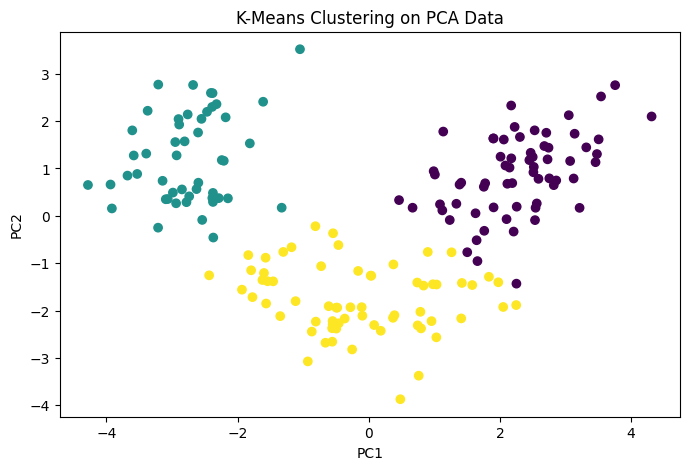

In [95]:
# Visualizing PCA clusters

plt.figure(figsize=(8,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=pca_clusters,
    cmap="viridis"
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("K-Means Clustering on PCA Data")

plt.show()

In [96]:
# Silhouette Score

from sklearn.metrics import silhouette_score

pca_silhouette = silhouette_score(
    X_pca,
    pca_clusters
)

print("PCA Silhouette Score :",
      pca_silhouette)

PCA Silhouette Score : 0.5610505693103248


In [97]:
# Davies-Bouldin Index

from sklearn.metrics import davies_bouldin_score

pca_db = davies_bouldin_score(
    X_pca,
    pca_clusters
)

print("PCA Davies-Bouldin Index :",
      pca_db)

PCA Davies-Bouldin Index : 0.5972661544221362


**TASK-5**

**Comparison of Clustering Results**


The clustering results obtained from the original dataset and PCA-transformed dataset were compared using Silhouette Score and Davies-Bouldin Index.


Original Data:
Silhouette Score = 0.2849

Davies-Bouldin Index = 1.3892


PCA Data:
Silhouette Score = 0.5611

Davies-Bouldin Index = 0.5973


The PCA-transformed dataset achieved a higher Silhouette Score and a lower Davies-Bouldin Index compared to the original dataset, indicating better cluster separation and compactness.

**Similarities and Differences**

Both the original dataset and the PCA-transformed dataset produced meaningful clusters using the K-Means algorithm.

However, the PCA-transformed data showed more clearly separated clusters and improved clustering performance compared to the original dataset.

**Impact of PCA on Clustering Performance**

PCA reduced the dimensionality of the dataset while preserving most of the important information.

The reduction in dimensionality helped improve cluster quality by removing noise and redundant information.

As a result, clustering performance improved after applying PCA.

**Trade-Offs Between PCA and Original Data**

Using the original dataset preserves all available information but may contain noise and redundant features that can affect clustering quality.

Using PCA reduces dimensionality and computational complexity while improving cluster separation, but some information may be lost during the transformation process.

**TASK-6**

**Conclusion**


PCA and K-Means clustering were successfully applied to the wine dataset.

The PCA-transformed dataset produced better clustering results than the original dataset, as demonstrated by the higher Silhouette Score and lower Davies-Bouldin Index.

This indicates that dimensionality reduction improved the effectiveness of clustering.

**Practical Implications**


PCA helps simplify high-dimensional datasets by reducing the number of features while retaining important information.

Clustering can be used to identify natural groupings within data, which is useful in customer segmentation, anomaly detection, and pattern recognition.


**Recommendations**


PCA should be used when datasets contain many correlated features or high dimensionality.

Clustering can be applied directly to original data when preserving all information is important, but PCA is recommended when improved cluster quality and reduced computational complexity are desired.